# Eelbrain.boosting
### This document showcases the effects of the boosting function parameters.
Boosting function docs: https://eelbrain.readthedocs.io/en/stable/generated/eelbrain.boosting.html#eelbrain.boosting

In [1]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
from matplotlib import pyplot

In [2]:
# Configure the matplotlib figure style
FONT = 'Arial'
FONT_SIZE = 8
RC = {
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.transparent': True,
    # Font
    'font.family': 'sans-serif',
    'font.sans-serif': FONT,
    'font.size': FONT_SIZE,
    'figure.labelsize': FONT_SIZE,
    'figure.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,    
    'legend.fontsize': FONT_SIZE,
}
pyplot.rcParams.update(RC)

In [3]:
EXAMPLE_SUBJECT = 'S1'

# Load example EEG and envelope data for one subject
eeg_path = file_paths.EEG_DIR / EXAMPLE_SUBJECT / f"{EXAMPLE_SUBJECT}_eeg.pickle"
eeg = eelbrain.load.unpickle(eeg_path)

# Load attended envelope for example subject
envelope_path = file_paths.ENVELOPES_DIR / EXAMPLE_SUBJECT / f"{EXAMPLE_SUBJECT}_attended_envelope.pickle"
envelope = eelbrain.load.unpickle(envelope_path)

## Forward and backwards model

In [4]:
simple_encoder = eelbrain.boosting(eeg, envelope, 0, 0.500)
simple_decoder = eelbrain.boosting(envelope, eeg, -0.500, 0)

In [5]:
print("Time it took to run the boosting forward (encoder) model:", simple_encoder.t_run)
print("Time it took to run the boosting backward (decoder) model:", simple_decoder.t_run)

Time it took to run the boosting forward (encoder) model: 8.755366086959839
Time it took to run the boosting backward (decoder) model: 29.708204984664917


In [11]:
print("Proportion of variance explained by the forward (encoder) model:", simple_encoder.proportion_explained, ", Mean over sensors: ", simple_encoder.proportion_explained.mean())
print("Proportion of variance explained by the backward (decoder) model:", simple_decoder.proportion_explained)

Proportion of variance explained by the forward (encoder) model: <NDVar '1': 64 sensor> , Mean over sensors:  0.0006790993238133588
Proportion of variance explained by the backward (decoder) model: 0.005029907040325021


## Error function
Can be 'l1' or 'l2'

In [7]:
simple_encoder_err_l1 = eelbrain.boosting(eeg, envelope, 0, 0.500, error='l1')
simple_decoder_err_l2 = eelbrain.boosting(envelope, eeg, -0.500, 0, error='l2')

In [12]:
print("Residual error of the forward (encoder) model with L1 error:", simple_encoder_err_l1.residual, ", Mean over sensors: ", simple_encoder_err_l1.residual.mean())
print("Residual error of the backward (decoder) model with L2 error:", simple_decoder_err_l2.residual)

Residual error of the forward (encoder) model with L1 error: <NDVar 'L1 residuals': 64 sensor> , Mean over sensors:  191822.99103678437
Residual error of the backward (decoder) model with L2 error: 191034.2578482576


## Basis function

In [13]:
simple_encoder_basis_50 = eelbrain.boosting(eeg, envelope, 0, 0.500, basis=0.050, basis_window='hamming')
simple_decoder_basis_50 = eelbrain.boosting(envelope, eeg, -0.500, 0, basis=0.050, basis_window='hamming')

In [22]:
simple_encoder_basis_100 = eelbrain.boosting(eeg, envelope, 0, 0.500, basis=0.100, basis_window='hamming')
simple_decoder_basis_100 = eelbrain.boosting(envelope, eeg, -0.500, 0, basis=0.100, basis_window='hamming')

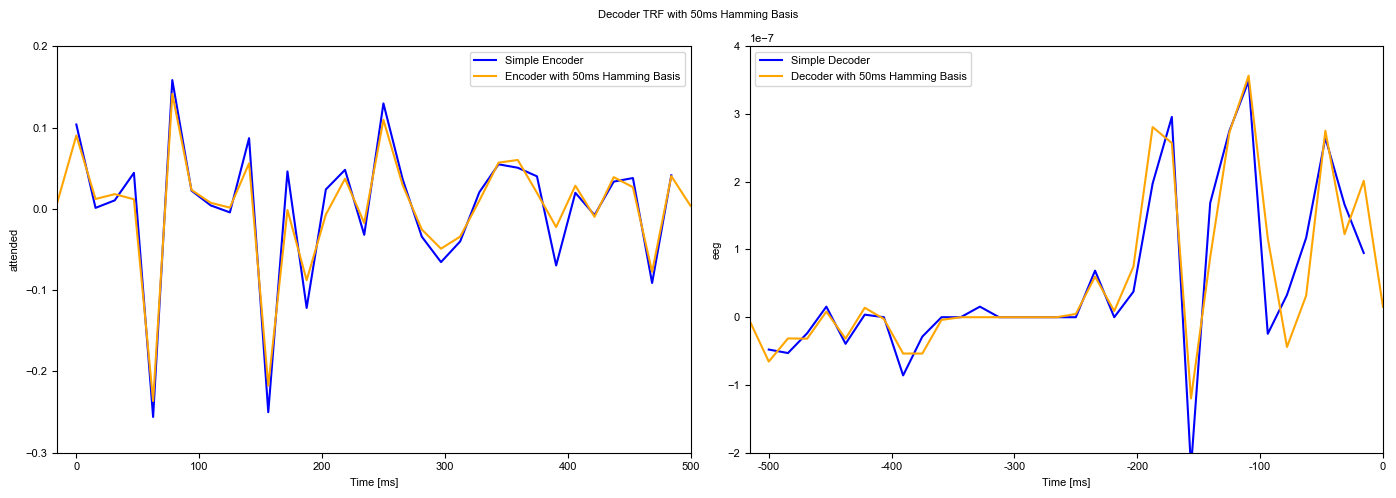

In [36]:
# Plot simple encoder vs encoder with basis functions
fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

eelbrain.plot.UTS(simple_encoder.h_scaled.mean("sensor"), axes=axes[0], title="Simple Encoder TRF", color='blue')
eelbrain.plot.UTS(simple_encoder_basis_50.h_scaled.mean("sensor"), axes=axes[0], title="Encoder TRF with 50ms Hamming Basis", color='orange')
#eelbrain.plot.UTS(simple_encoder_basis_100.h_scaled.mean("sensor"), axes=axes[0], title="Encoder TRF with 100ms Hamming Basis", color='green')
axes[0].legend(['Simple Encoder', 'Encoder with 50ms Hamming Basis', 'Encoder with 100ms Hamming Basis'])


eelbrain.plot.UTS(simple_decoder.h_scaled.mean("sensor"), axes=axes[1], title="Simple Decoder TRF", color='blue')
eelbrain.plot.UTS(simple_decoder_basis_50.h_scaled.mean("sensor"), axes=axes[1], title="Decoder TRF with 50ms Hamming Basis", color='orange')
#eelbrain.plot.UTS(simple_decoder_basis_100.h_scaled.mean("sensor"), axes=axes[1], title="Decoder TRF with 100ms Hamming Basis", color='green')
axes[1].legend(['Simple Decoder', 'Decoder with 50ms Hamming Basis', 'Decoder with 100ms Hamming Basis'])
pyplot.tight_layout()
pyplot.show()  

## Cross validation

In [37]:
simple_encoder_cross_validated = eelbrain.boosting(eeg, envelope, 0, 0.500, test=True)
simple_decoder_cross_validated = eelbrain.boosting(envelope, eeg, -0.500, 0, test=True)

In [39]:
print("Proportion of variance explained by the forward (encoder) model:", simple_encoder.proportion_explained, ", Mean over sensors: ", simple_encoder.proportion_explained.mean())
print("Proportion of variance explained by the forward (encoder) model cross-validated:", simple_encoder_cross_validated.proportion_explained, ", Mean over sensors: ", simple_encoder_cross_validated.proportion_explained.mean())
print(" ")
print("Proportion of variance explained by the backward (decoder) model:", simple_decoder.proportion_explained)
print("Proportion of variance explained by the backward (decoder) model cross-validated:", simple_decoder_cross_validated.proportion_explained)

Proportion of variance explained by the forward (encoder) model: <NDVar '1': 64 sensor> , Mean over sensors:  0.0006790993238133588
Proportion of variance explained by the forward (encoder) model cross-validated: <NDVar '1': 64 sensor> , Mean over sensors:  0.0002551732625047671
 
Proportion of variance explained by the backward (decoder) model: 0.005029907040325021
Proportion of variance explained by the backward (decoder) model cross-validated: 0.003092149450410364
